# SimpleOCRAgent System Architecture

## Overview

This notebook provides a comprehensive technical analysis of the **SimpleOCRAgent** system, a LangGraph-based multimodal UI automation agent designed for Android interface interaction using the Android in the Wild (AiTW) dataset.

### Key Features:
- **Single-node LangGraph architecture** with episode-based execution
- **Persistent state management** using LangGraph's MemorySaver
- **OCR-enhanced vision capabilities** for UI element detection
- **Structured action output** compatible with AiTW action schemas
- **Thread-based session isolation** for multiple concurrent interactions

The system demonstrates sophisticated agent orchestration patterns while maintaining simplicity through a unified model node approach.

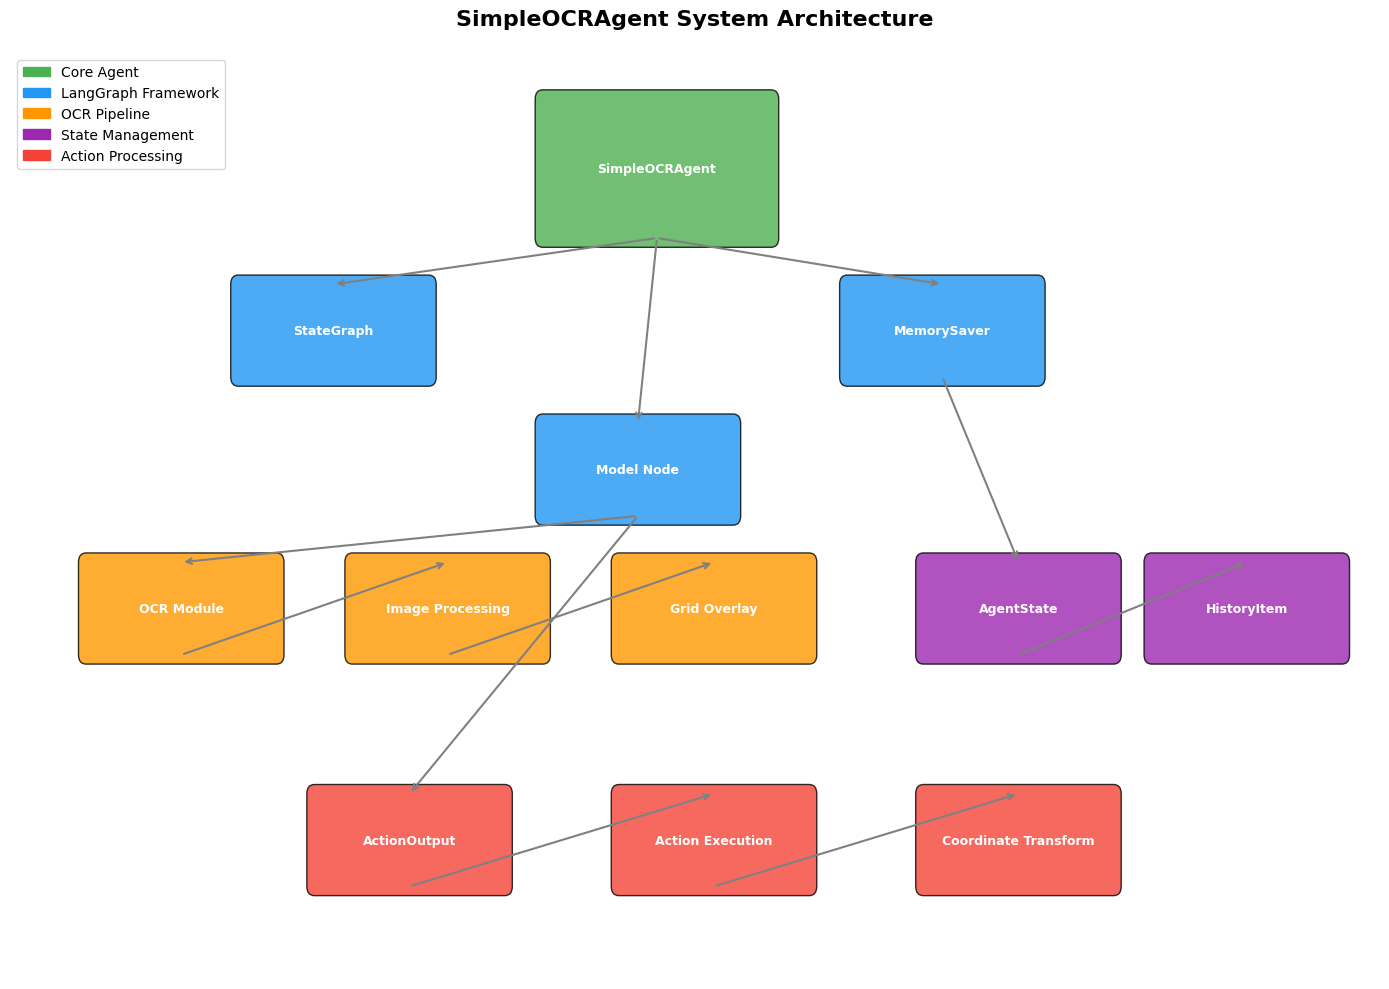

In [1]:
# Import necessary libraries for visualization and analysis
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, ConnectionPatch
import numpy as np
from typing import Dict, List, Any, Optional
import json

# Set up plotting style
plt.style.use('default')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

# Function to create architecture diagrams
def create_architecture_diagram():
    """Create a high-level system architecture diagram"""
    fig, ax = plt.subplots(1, 1, figsize=(14, 10))
    
    # Define colors
    colors = {
        'agent': '#4CAF50',      # Green for main agent
        'langgraph': '#2196F3',  # Blue for LangGraph components
        'ocr': '#FF9800',        # Orange for OCR components
        'data': '#9C27B0',       # Purple for data/state
        'action': '#F44336'      # Red for actions
    }
    
    # Main components
    components = [
        # Core Agent
        {'name': 'SimpleOCRAgent', 'pos': (7, 8), 'size': (3, 1.5), 'color': colors['agent']},
        
        # LangGraph Components
        {'name': 'StateGraph', 'pos': (3, 6.5), 'size': (2.5, 1), 'color': colors['langgraph']},
        {'name': 'MemorySaver', 'pos': (11, 6.5), 'size': (2.5, 1), 'color': colors['langgraph']},
        {'name': 'Model Node', 'pos': (7, 5), 'size': (2.5, 1), 'color': colors['langgraph']},
        
        # OCR Pipeline
        {'name': 'OCR Module', 'pos': (1, 3.5), 'size': (2.5, 1), 'color': colors['ocr']},
        {'name': 'Image Processing', 'pos': (4.5, 3.5), 'size': (2.5, 1), 'color': colors['ocr']},
        {'name': 'Grid Overlay', 'pos': (8, 3.5), 'size': (2.5, 1), 'color': colors['ocr']},
        
        # State Management
        {'name': 'AgentState', 'pos': (12, 3.5), 'size': (2.5, 1), 'color': colors['data']},
        {'name': 'HistoryItem', 'pos': (15, 3.5), 'size': (2.5, 1), 'color': colors['data']},
        
        # Action Output
        {'name': 'ActionOutput', 'pos': (4, 1), 'size': (2.5, 1), 'color': colors['action']},
        {'name': 'Action Execution', 'pos': (8, 1), 'size': (2.5, 1), 'color': colors['action']},
        {'name': 'Coordinate Transform', 'pos': (12, 1), 'size': (2.5, 1), 'color': colors['action']},
    ]
    
    # Draw components
    boxes = {}
    for comp in components:
        box = FancyBboxPatch(
            comp['pos'], comp['size'][0], comp['size'][1],
            boxstyle="round,pad=0.1",
            facecolor=comp['color'],
            edgecolor='black',
            alpha=0.8
        )
        ax.add_patch(box)
        
        # Add text
        ax.text(
            comp['pos'][0] + comp['size'][0]/2,
            comp['pos'][1] + comp['size'][1]/2,
            comp['name'],
            ha='center', va='center',
            fontweight='bold',
            fontsize=9,
            color='white'
        )
        boxes[comp['name']] = comp
    
    # Define connections
    connections = [
        ('SimpleOCRAgent', 'StateGraph'),
        ('SimpleOCRAgent', 'MemorySaver'),
        ('SimpleOCRAgent', 'Model Node'),
        ('Model Node', 'OCR Module'),
        ('Model Node', 'ActionOutput'),
        ('OCR Module', 'Image Processing'),
        ('Image Processing', 'Grid Overlay'),
        ('AgentState', 'HistoryItem'),
        ('ActionOutput', 'Action Execution'),
        ('Action Execution', 'Coordinate Transform'),
        ('MemorySaver', 'AgentState'),
    ]
    
    # Draw connections
    for start, end in connections:
        start_comp = boxes[start]
        end_comp = boxes[end]
        
        start_x = start_comp['pos'][0] + start_comp['size'][0]/2
        start_y = start_comp['pos'][1]
        end_x = end_comp['pos'][0] + end_comp['size'][0]/2
        end_y = end_comp['pos'][1] + end_comp['size'][1]
        
        ax.annotate('', xy=(end_x, end_y), xytext=(start_x, start_y),
                   arrowprops=dict(arrowstyle='->', lw=1.5, color='gray'))
    
    # Add title and labels
    ax.set_title('SimpleOCRAgent System Architecture', fontsize=16, fontweight='bold', pad=20)
    
    # Create legend
    legend_elements = [
        mpatches.Patch(color=colors['agent'], label='Core Agent'),
        mpatches.Patch(color=colors['langgraph'], label='LangGraph Framework'),
        mpatches.Patch(color=colors['ocr'], label='OCR Pipeline'),
        mpatches.Patch(color=colors['data'], label='State Management'),
        mpatches.Patch(color=colors['action'], label='Action Processing')
    ]
    ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(0, 1))
    
    # Set limits and hide axes
    ax.set_xlim(0, 18)
    ax.set_ylim(0, 10)
    ax.axis('off')
    
    plt.tight_layout()
    plt.show()

# Create the architecture diagram
create_architecture_diagram()

## Section 2: LangGraph State Management

The `SimpleOCRAgent` uses LangGraph's StateGraph for orchestrating UI automation workflows. The system maintains state through TypedDict structures and ensures persistence across episodes using MemorySaver.

### Key Components:
- **AgentState**: Central state container for current context and history
- **HistoryItem**: Individual interaction records with UI context and actions
- **MemorySaver**: LangGraph's checkpointer for persistent state management
- **Thread Isolation**: Separate conversation contexts using thread_id

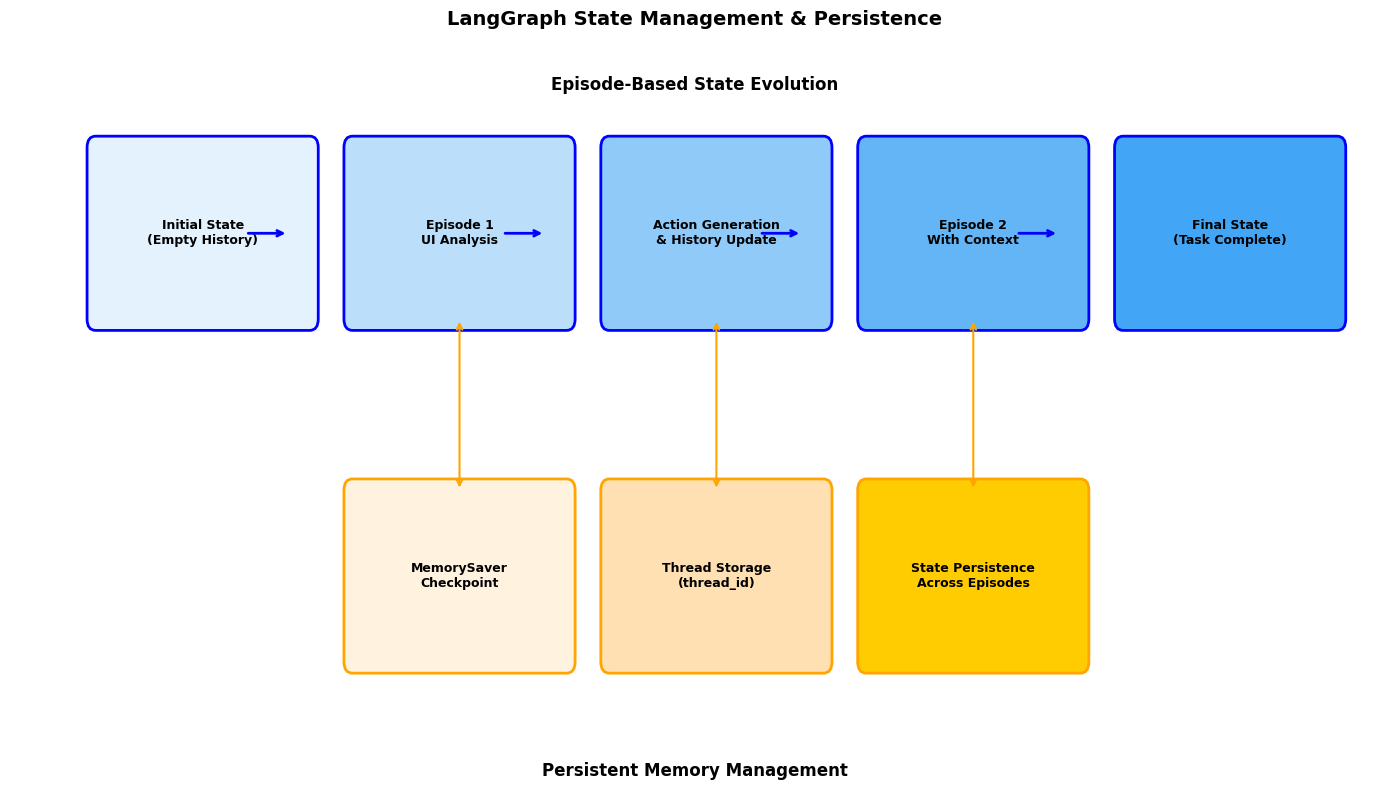

Example AgentState Structure:
{
  "history": [
    {
      "image": "screenshot1.png",
      "ocr": "Username: [field] Password: [field] Login",
      "ui_description": "Login screen with empty fields",
      "goal": "Log into application",
      "action_taken": {
        "action_type": 4,
        "coordinates": [
          0.5,
          0.3
        ]
      },
      "task_done": false
    }
  ],
  "current_image": "screenshot2.png",
  "current_ocr": "Username: john Password: [field] Login",
  "current_ui_description": "Login screen with username filled",
  "goal": "Log into application",
  "action": null,
  "task_completed": false
}


In [2]:
# Demonstrate the AgentState and HistoryItem structures
from typing import TypedDict, Annotated, List, Dict, Any, Optional
from dataclasses import dataclass

# AgentState TypedDict structure
class AgentState(TypedDict):
    """State schema for the LangGraph agent"""
    history: Annotated[List, lambda x, y: x + y]  # History of past interactions
    current_image: Any                             # Current UI screenshot
    current_ocr: str                              # Current OCR text
    current_ui_description: str                   # Current UI description
    goal: str                                     # Overall goal/task
    action: Optional[Dict[str, Any]]              # Current action to take
    task_completed: bool                          # Whether the overall task is done

@dataclass
class HistoryItem:
    """Single interaction history item containing UI state and action taken"""
    image: Any                                    # PIL Image or image path
    ocr: str                                     # OCR text extracted from the image
    ui_description: str                          # String describing the current UI state
    goal: str                                    # Current goal/task description
    action_taken: Optional[Dict[str, Any]] = None # Action that was taken
    task_done: bool = False                      # Whether the task is completed

# Visualize state transitions
def create_state_flow_diagram():
    """Create a diagram showing state transitions and persistence"""
    fig, ax = plt.subplots(1, 1, figsize=(14, 8))
    
    # Define state boxes
    states = [
        {'name': 'Initial State\n(Empty History)', 'pos': (1, 6), 'color': '#E3F2FD'},
        {'name': 'Episode 1\nUI Analysis', 'pos': (4, 6), 'color': '#BBDEFB'},
        {'name': 'Action Generation\n& History Update', 'pos': (7, 6), 'color': '#90CAF9'},
        {'name': 'Episode 2\nWith Context', 'pos': (10, 6), 'color': '#64B5F6'},
        {'name': 'Final State\n(Task Complete)', 'pos': (13, 6), 'color': '#42A5F5'},
    ]
    
    # Memory management boxes
    memory_states = [
        {'name': 'MemorySaver\nCheckpoint', 'pos': (4, 3), 'color': '#FFF3E0'},
        {'name': 'Thread Storage\n(thread_id)', 'pos': (7, 3), 'color': '#FFE0B2'},
        {'name': 'State Persistence\nAcross Episodes', 'pos': (10, 3), 'color': '#FFCC02'},
    ]
    
    # Draw state boxes
    for state in states:
        box = FancyBboxPatch(
            state['pos'], 2.5, 1.5,
            boxstyle="round,pad=0.1",
            facecolor=state['color'],
            edgecolor='blue',
            linewidth=2
        )
        ax.add_patch(box)
        ax.text(state['pos'][0] + 1.25, state['pos'][1] + 0.75, state['name'],
                ha='center', va='center', fontweight='bold', fontsize=9)
    
    # Draw memory boxes
    for mem in memory_states:
        box = FancyBboxPatch(
            mem['pos'], 2.5, 1.5,
            boxstyle="round,pad=0.1",
            facecolor=mem['color'],
            edgecolor='orange',
            linewidth=2
        )
        ax.add_patch(box)
        ax.text(mem['pos'][0] + 1.25, mem['pos'][1] + 0.75, mem['name'],
                ha='center', va='center', fontweight='bold', fontsize=9)
    
    # Draw arrows between states
    arrow_positions = [(2.75, 6.75), (5.75, 6.75), (8.75, 6.75), (11.75, 6.75)]
    for i, pos in enumerate(arrow_positions):
        ax.annotate('', xy=(pos[0] + 0.5, pos[1]), xytext=(pos[0], pos[1]),
                   arrowprops=dict(arrowstyle='->', lw=2, color='blue'))
    
    # Draw memory connections
    memory_arrows = [
        ((5.25, 4.5), (5.25, 6)),
        ((8.25, 4.5), (8.25, 6)),
        ((11.25, 4.5), (11.25, 6))
    ]
    for start, end in memory_arrows:
        ax.annotate('', xy=end, xytext=start,
                   arrowprops=dict(arrowstyle='<->', lw=1.5, color='orange'))
    
    ax.set_title('LangGraph State Management & Persistence', fontsize=14, fontweight='bold')
    ax.set_xlim(0, 16)
    ax.set_ylim(2, 8.5)
    ax.axis('off')
    
    # Add labels
    ax.text(8, 8, 'Episode-Based State Evolution', ha='center', fontsize=12, fontweight='bold')
    ax.text(8, 2, 'Persistent Memory Management', ha='center', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

create_state_flow_diagram()

# Example state structure
print("Example AgentState Structure:")
example_state = {
    "history": [
        {
            "image": "screenshot1.png",
            "ocr": "Username: [field] Password: [field] Login",
            "ui_description": "Login screen with empty fields",
            "goal": "Log into application",
            "action_taken": {"action_type": 4, "coordinates": [0.5, 0.3]},
            "task_done": False
        }
    ],
    "current_image": "screenshot2.png",
    "current_ocr": "Username: john Password: [field] Login",
    "current_ui_description": "Login screen with username filled",
    "goal": "Log into application",
    "action": None,
    "task_completed": False
}

print(json.dumps(example_state, indent=2))

## Section 3: Agent Components and Flow

The `SimpleOCRAgent` follows a **single-node architecture** where all decision-making happens in one model node. This design prioritizes simplicity while maintaining sophisticated capabilities through episode-based execution.

### Architecture Pattern:
```
START → model_node → conditional_edge → {continue: END, end: END}
```

### Key Components:
- **Single Model Node**: Handles UI analysis, action decisions, and history updates
- **Conditional Routing**: Determines whether to continue or end based on task completion
- **Episode-Based Execution**: Processes one UI state at a time
- **Memory Persistence**: Maintains context across episodes using thread-based storage

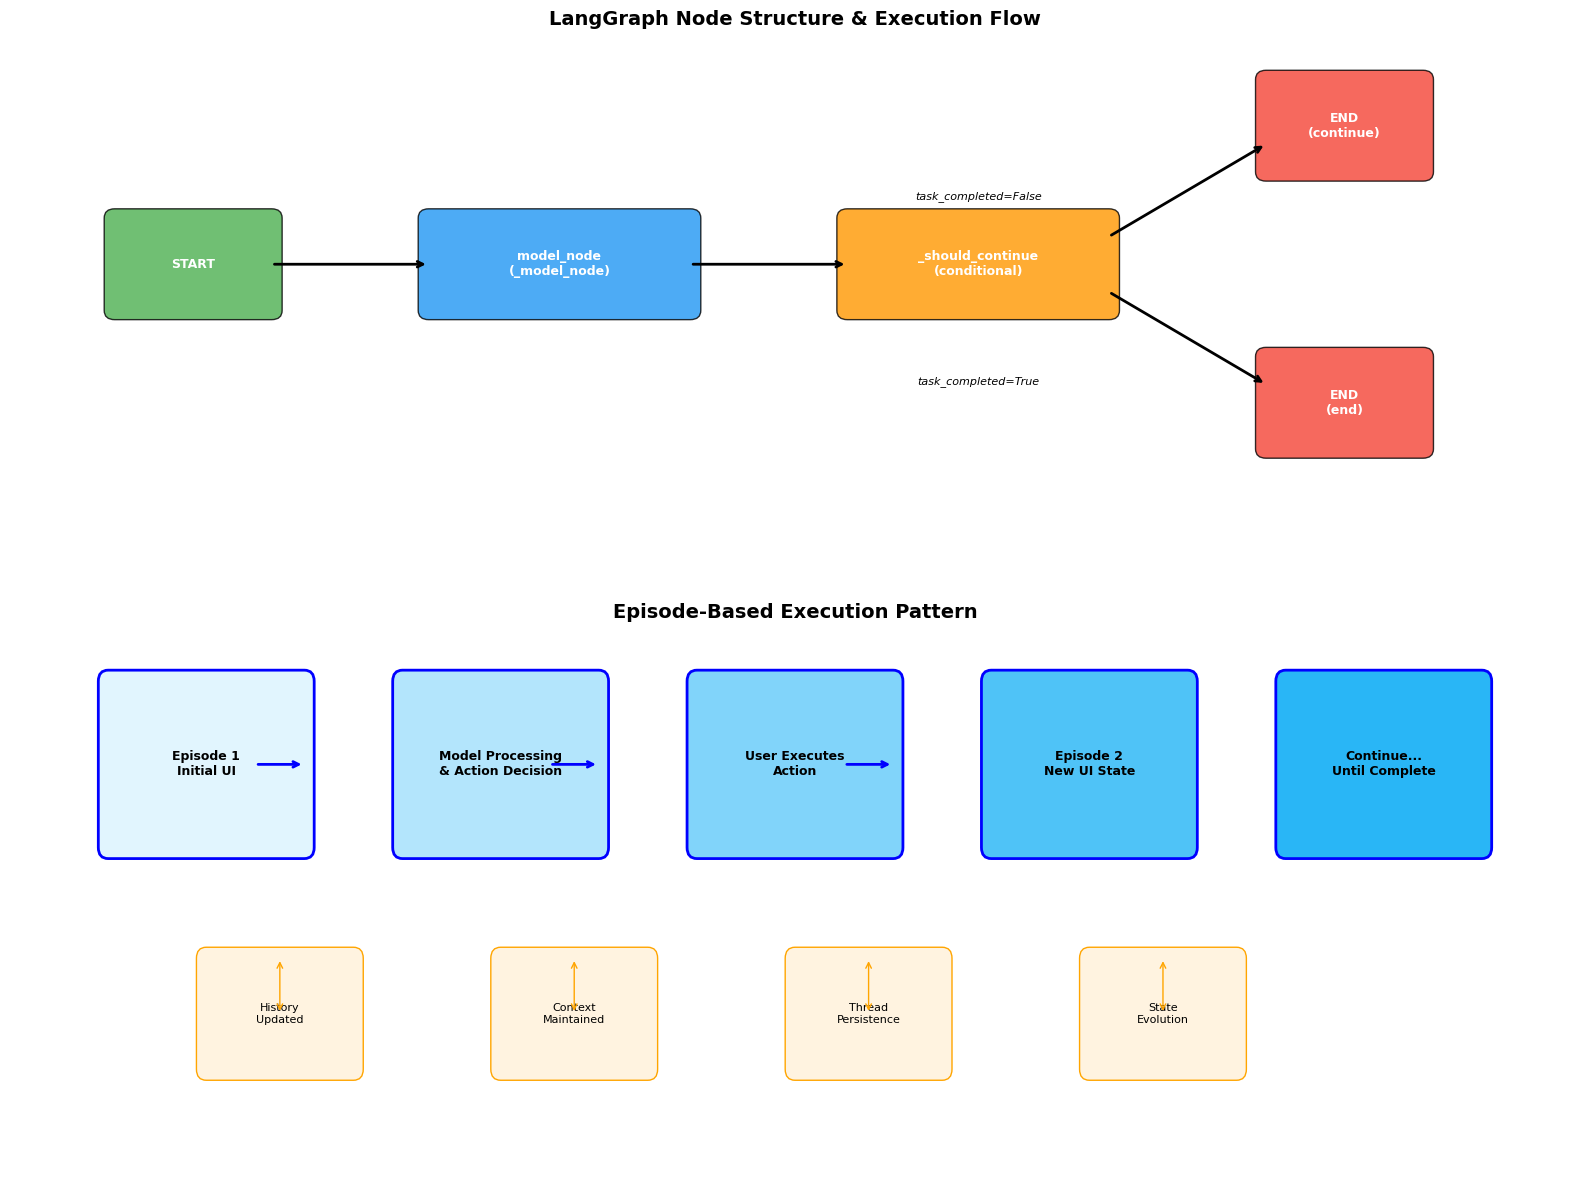

LangGraph Construction Pattern:

# Create the state graph
self.graph_builder = StateGraph(AgentState)

# Add single model node
self.graph_builder.add_node("model", self._model_node)

# Add conditional edges
self.graph_builder.add_conditional_edges(
    "model",
    self._should_continue,
    {
        "continue": END,  # Wait for next user input
        "end": END        # Task completed
    }
)

# Set entry point
self.graph_builder.set_entry_point("model")

# Compile with memory
memory = MemorySaver()
self.graph = self.graph_builder.compile(checkpointer=memory)



In [3]:
# Create detailed agent flow diagram
def create_agent_flow_diagram():
    """Create a detailed flow diagram showing the single-node architecture"""
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12))
    
    # Top diagram: LangGraph Structure
    ax1.set_title('LangGraph Node Structure & Execution Flow', fontsize=14, fontweight='bold')
    
    # LangGraph components
    components = [
        {'name': 'START', 'pos': (1, 5), 'size': (1.5, 1), 'color': '#4CAF50'},
        {'name': 'model_node\n(_model_node)', 'pos': (4, 5), 'size': (2.5, 1), 'color': '#2196F3'},
        {'name': '_should_continue\n(conditional)', 'pos': (8, 5), 'size': (2.5, 1), 'color': '#FF9800'},
        {'name': 'END\n(continue)', 'pos': (12, 6.5), 'size': (1.5, 1), 'color': '#F44336'},
        {'name': 'END\n(end)', 'pos': (12, 3.5), 'size': (1.5, 1), 'color': '#F44336'},
    ]
    
    # Draw components
    for comp in components:
        box = FancyBboxPatch(
            comp['pos'], comp['size'][0], comp['size'][1],
            boxstyle="round,pad=0.1",
            facecolor=comp['color'],
            edgecolor='black',
            alpha=0.8
        )
        ax1.add_patch(box)
        ax1.text(comp['pos'][0] + comp['size'][0]/2, comp['pos'][1] + comp['size'][1]/2,
                comp['name'], ha='center', va='center', fontweight='bold', 
                fontsize=9, color='white')
    
    # Draw arrows
    arrows = [
        ((2.5, 5.5), (4, 5.5)),      # START → model_node
        ((6.5, 5.5), (8, 5.5)),      # model_node → conditional
        ((10.5, 5.8), (12, 6.8)),    # conditional → END (continue)
        ((10.5, 5.2), (12, 4.2)),    # conditional → END (end)
    ]
    
    for start, end in arrows:
        ax1.annotate('', xy=end, xytext=start,
                    arrowprops=dict(arrowstyle='->', lw=2, color='black'))
    
    # Add labels
    ax1.text(9.25, 6.2, 'task_completed=False', ha='center', fontsize=8, style='italic')
    ax1.text(9.25, 4.2, 'task_completed=True', ha='center', fontsize=8, style='italic')
    
    ax1.set_xlim(0, 15)
    ax1.set_ylim(2, 8)
    ax1.axis('off')
    
    # Bottom diagram: Episode-Based Execution
    ax2.set_title('Episode-Based Execution Pattern', fontsize=14, fontweight='bold')
    
    episodes = [
        {'name': 'Episode 1\nInitial UI', 'pos': (1, 3), 'color': '#E1F5FE'},
        {'name': 'Model Processing\n& Action Decision', 'pos': (4, 3), 'color': '#B3E5FC'},
        {'name': 'User Executes\nAction', 'pos': (7, 3), 'color': '#81D4FA'},
        {'name': 'Episode 2\nNew UI State', 'pos': (10, 3), 'color': '#4FC3F7'},
        {'name': 'Continue...\nUntil Complete', 'pos': (13, 3), 'color': '#29B6F6'},
    ]
    
    for ep in episodes:
        box = FancyBboxPatch(
            ep['pos'], 2, 1.5,
            boxstyle="round,pad=0.1",
            facecolor=ep['color'],
            edgecolor='blue',
            linewidth=2
        )
        ax2.add_patch(box)
        ax2.text(ep['pos'][0] + 1, ep['pos'][1] + 0.75, ep['name'],
                ha='center', va='center', fontweight='bold', fontsize=9)
    
    # Episode arrows
    ep_arrows = [(2.5, 3.75), (5.5, 3.75), (8.5, 3.75), (11.5, 3.75)]
    for i, pos in enumerate(ep_arrows):
        if i < len(ep_arrows) - 1:
            ax2.annotate('', xy=(pos[0] + 0.5, pos[1]), xytext=(pos[0], pos[1]),
                        arrowprops=dict(arrowstyle='->', lw=2, color='blue'))
    
    # Add memory persistence indicators
    memory_boxes = [
        {'pos': (2, 1), 'text': 'History\nUpdated'},
        {'pos': (5, 1), 'text': 'Context\nMaintained'},
        {'pos': (8, 1), 'text': 'Thread\nPersistence'},
        {'pos': (11, 1), 'text': 'State\nEvolution'},
    ]
    
    for mem in memory_boxes:
        box = FancyBboxPatch(
            mem['pos'], 1.5, 1,
            boxstyle="round,pad=0.1",
            facecolor='#FFF3E0',
            edgecolor='orange',
            linewidth=1
        )
        ax2.add_patch(box)
        ax2.text(mem['pos'][0] + 0.75, mem['pos'][1] + 0.5, mem['text'],
                ha='center', va='center', fontsize=8)
        
        # Connect to episodes
        ax2.annotate('', xy=(mem['pos'][0] + 0.75, mem['pos'][1] + 1), 
                    xytext=(mem['pos'][0] + 0.75, mem['pos'][1] + 0.5),
                    arrowprops=dict(arrowstyle='<->', lw=1, color='orange'))
    
    ax2.set_xlim(0, 16)
    ax2.set_ylim(0, 5)
    ax2.axis('off')
    
    plt.tight_layout()
    plt.show()

create_agent_flow_diagram()

# Show the actual LangGraph construction code structure
print("LangGraph Construction Pattern:")
print("""
# Create the state graph
self.graph_builder = StateGraph(AgentState)

# Add single model node
self.graph_builder.add_node("model", self._model_node)

# Add conditional edges
self.graph_builder.add_conditional_edges(
    "model",
    self._should_continue,
    {
        "continue": END,  # Wait for next user input
        "end": END        # Task completed
    }
)

# Set entry point
self.graph_builder.set_entry_point("model")

# Compile with memory
memory = MemorySaver()
self.graph = self.graph_builder.compile(checkpointer=memory)
""")

## Section 4: OCR and Image Processing Pipeline

The OCR module enhances the agent's visual understanding through sophisticated image processing and UI element extraction. When enabled, it provides precise coordinate information and visual calibration aids.

### Pipeline Components:
- **Tesseract OCR**: Text extraction with confidence filtering
- **Image Preprocessing**: Adaptive thresholding and noise reduction
- **Grid Overlay System**: Visual calibration with anchor points
- **Coordinate Normalization**: Conversion to [0,1] range for consistency
- **Base64 Conversion**: Multimodal message formatting for LLM consumption